# Statistical Business Analysis

## Project Overview
This project performs statistical analysis on business sales data.

### Objectives
- Calculate descriptive statistics
- Analyze data distributions and normality
- Perform Pearson correlation analysis
- Conduct at least three hypothesis tests
- Calculate 95% confidence intervals and margin of error
- Perform linear regression and calculate R-squared
- Translate statistical findings into business insights

> **Dataset note:** The provided sales dataset does not contain a Marketing Spend column. Therefore, this analysis uses the available business variables—especially `Quantity`, `Price`, `Total_Sales`, `Product`, and `Region`—instead of inventing a marketing-spend variable.


In [1]:
# 1. Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_1samp, ttest_ind, f_oneway, shapiro, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Libraries imported successfully.")

# Load dataset
df = pd.read_csv("business_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Libraries imported successfully.
Dataset loaded successfully!
Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


## 2. Load Dataset

In [2]:
# Load the business dataset
file_path = "business_data.csv"
df = pd.read_csv(file_path)

# Standardize column names
df.columns = [c.strip().replace(" ", "_") for c in df.columns]

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
# Basic dataset information
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Column names:
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']

Data types:
Date             str
Product          str
Quantity       int64
Price          int64
Customer_ID      str
Region           str
Total_Sales    int64
dtype: object

Missing values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate rows: 0


In [4]:
# Basic cleaning
numeric_columns = ["Quantity", "Price", "Total_Sales"]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[c for c in numeric_columns if c in df.columns]).copy()

print("Shape after cleaning:", df.shape)


Shape after cleaning: (100, 7)


## 3. Descriptive Statistics

The following section calculates count, mean, median, mode, standard deviation, variance, minimum, maximum, range, and quartiles for the main numerical business variables.


In [5]:
# Descriptive statistics
numeric = df.select_dtypes(include=np.number)

descriptive = pd.DataFrame({
    "Count": numeric.count(),
    "Mean": numeric.mean(),
    "Median": numeric.median(),
    "Mode": numeric.mode().iloc[0],
    "Standard_Deviation": numeric.std(),
    "Variance": numeric.var(),
    "Minimum": numeric.min(),
    "Q1": numeric.quantile(0.25),
    "Q3": numeric.quantile(0.75),
    "Maximum": numeric.max(),
})

descriptive["Range"] = descriptive["Maximum"] - descriptive["Minimum"]

descriptive.round(3)


,Count,Mean,Median,Mode,Standard_Deviation,Variance,Minimum,Q1,Q3,Maximum,Range
Quantity,100,4.780,5.000,4.000,2.588,6.699,1,2.750,7.000,9,8
Price,100,"25,808.510","24,192.000","1,308.000","13,917.630","193,700,431.545",1308,"14,965.250","38,682.250",49930,48622
Total_Sales,100,"123,650.480","97,955.500","6,540.000","100,161.085","10,032,243,003.464",6540,"39,517.500","175,792.500",373932,367392


### Descriptive Statistics Summary

In [6]:
print("Mean values:")
print(numeric.mean().round(3))

print("\nMedian values:")
print(numeric.median().round(3))

print("\nMode values:")
print(numeric.mode().iloc[0].round(3))

print("\nStandard deviations:")
print(numeric.std().round(3))


Mean values:
Quantity            4.780
Price          25,808.510
Total_Sales   123,650.480
dtype: float64

Median values:
Quantity           5.000
Price         24,192.000
Total_Sales   97,955.500
dtype: float64

Mode values:
Quantity          4.000
Price         1,308.000
Total_Sales   6,540.000
Name: 0, dtype: float64

Standard deviations:
Quantity            2.588
Price          13,917.630
Total_Sales   100,161.085
dtype: float64


## 4. Data Distribution Analysis

Histograms are created for the main numerical variables. A Shapiro-Wilk normality test is also performed.

### Interpretation
- **p-value > 0.05:** insufficient evidence to reject normality.
- **p-value ≤ 0.05:** evidence that the data differs from a normal distribution.

The normality test is used as a statistical diagnostic; it does not determine business importance by itself.


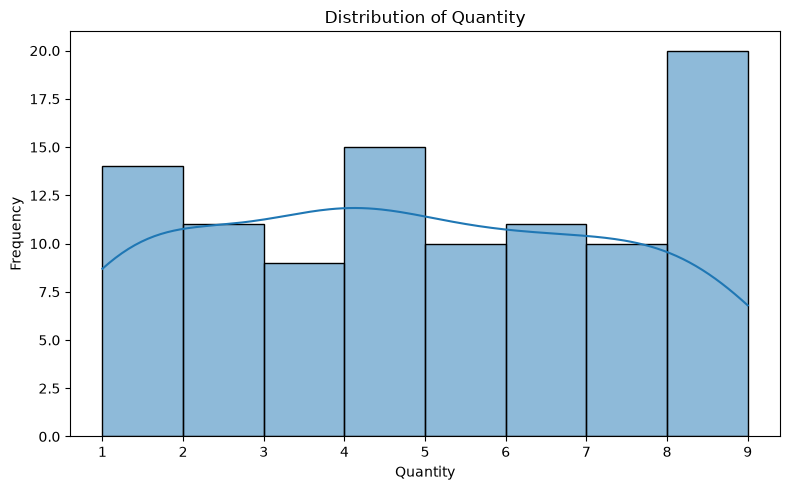

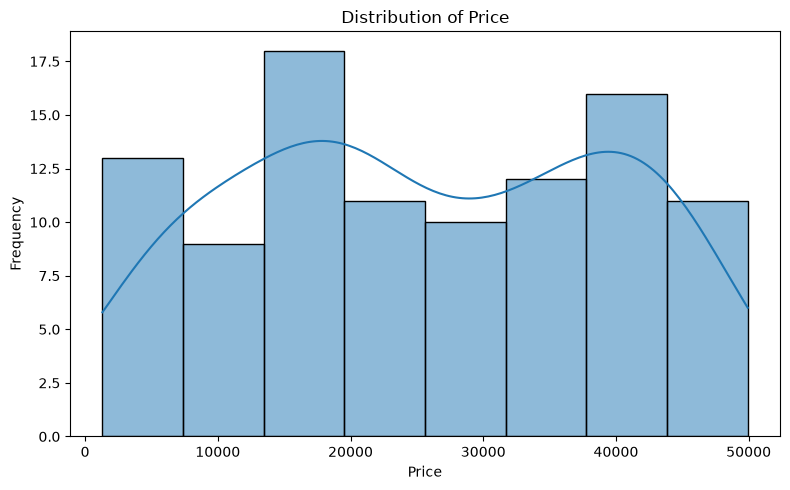

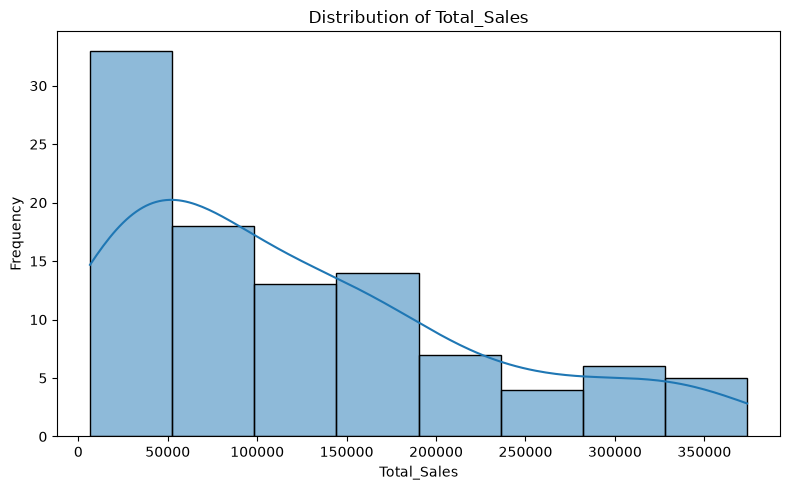

In [7]:
# Histograms
for col in ["Quantity", "Price", "Total_Sales"]:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


In [8]:
# Shapiro-Wilk normality tests
normality_results = []

for col in ["Quantity", "Price", "Total_Sales"]:
    if col in df.columns:
        # Shapiro is most commonly used with samples up to 5000 observations
        sample = df[col].dropna()
        stat, p = shapiro(sample)
        normality_results.append({
            "Variable": col,
            "Shapiro_Statistic": stat,
            "p_value": p,
            "Result_at_0.05": "Approximately normal" if p > 0.05 else "Not normally distributed"
        })

normality_df = pd.DataFrame(normality_results)
normality_df.round(5)


,Variable,Shapiro_Statistic,p_value,Result_at_0.05
0,Quantity,0.930,0.000,Not normally distributed
1,Price,0.948,0.001,Not normally distributed
2,Total_Sales,0.899,0.000,Not normally distributed


## 5. Correlation Analysis

Because the provided dataset does not contain Marketing Spend or a separate Revenue field, Pearson correlation is performed on the available quantitative business variables.

In particular:
- Quantity vs Total Sales
- Price vs Total Sales
- Quantity vs Price

**Important:** Correlation measures association, not causation.


In [9]:
# Pearson correlation matrix
corr_matrix = df[["Quantity", "Price", "Total_Sales"]].corr(method="pearson")
corr_matrix.round(3)


,Quantity,Price,Total_Sales
Quantity,1.000,0.008,0.688
Price,0.008,1.000,0.646
Total_Sales,0.688,0.646,1.000


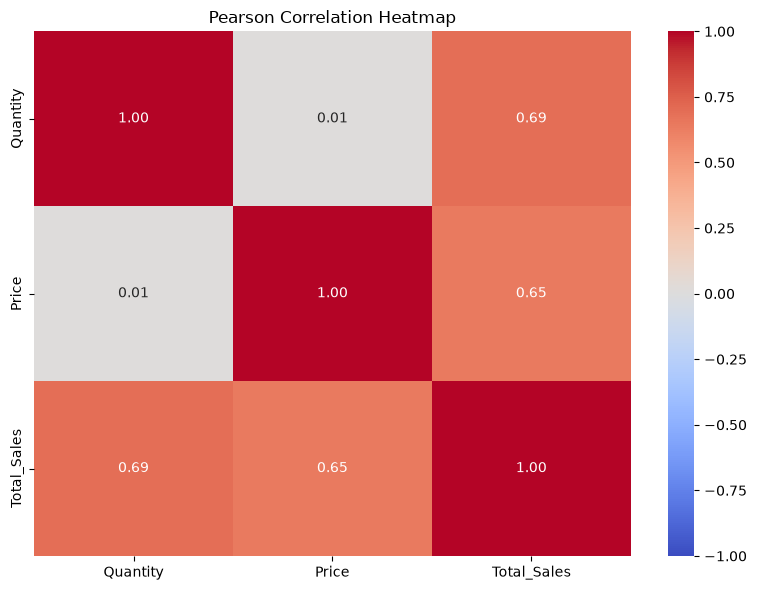

In [10]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()


In [11]:
# Individual Pearson correlation tests
pairs = [
    ("Quantity", "Total_Sales"),
    ("Price", "Total_Sales"),
    ("Quantity", "Price")
]

correlation_results = []

for x, y in pairs:
    r, p = pearsonr(df[x], df[y])
    correlation_results.append({
        "Variable_1": x,
        "Variable_2": y,
        "Pearson_r": r,
        "p_value": p,
        "Significant_at_0.05": "Yes" if p < 0.05 else "No"
    })

correlation_df = pd.DataFrame(correlation_results)
correlation_df.round(5)


,Variable_1,Variable_2,Pearson_r,p_value,Significant_at_0.05
0,Quantity,Total_Sales,0.688,0.000,Yes
1,Price,Total_Sales,0.646,0.000,Yes
2,Quantity,Price,0.008,0.937,No


## 6. Hypothesis Testing

Three hypothesis tests are performed at a significance level of **α = 0.05**:

1. One-sample t-test
2. Independent-samples t-test
3. One-way ANOVA

The tests use the actual structure of the supplied sales dataset.


### Test 1 — One-Sample t-Test

**Business question:** Is the average Total Sales value different from the dataset's median Total Sales?

- **H₀:** Mean Total Sales = sample median Total Sales
- **H₁:** Mean Total Sales ≠ sample median Total Sales

The benchmark is calculated from the supplied data so that the test is transparent and reproducible.


In [12]:
alpha = 0.05
sales = df["Total_Sales"].dropna()
benchmark = sales.median()

t1_stat, t1_p = ttest_1samp(sales, benchmark)

test1_result = {
    "Test": "One-sample t-test",
    "Benchmark": benchmark,
    "t_statistic": t1_stat,
    "p_value": t1_p,
    "alpha": alpha,
    "Decision": "Reject H0" if t1_p < alpha else "Fail to reject H0"
}

pd.DataFrame([test1_result]).round(5)


,Test,Benchmark,t_statistic,p_value,alpha,Decision
0,One-sample t-test,"97,955.500",2.565,0.012,0.050,Reject H0


### Test 2 — Independent-Samples t-Test

**Business question:** Do two major regions have different average Total Sales?

The two largest regions by number of observations are selected automatically.

- **H₀:** The mean Total Sales is equal for the two selected regions.
- **H₁:** The mean Total Sales differs between the two selected regions.

Welch's t-test is used because it does not require equal population variances.


In [13]:
# Select the two regions with the largest sample sizes
region_counts = df["Region"].value_counts()
top_two_regions = region_counts.head(2).index.tolist()

if len(top_two_regions) < 2:
    raise ValueError("At least two regions are required for the independent-samples t-test.")

region_a = df.loc[df["Region"] == top_two_regions[0], "Total_Sales"].dropna()
region_b = df.loc[df["Region"] == top_two_regions[1], "Total_Sales"].dropna()

t2_stat, t2_p = ttest_ind(region_a, region_b, equal_var=False)

test2_result = {
    "Test": "Independent-samples Welch t-test",
    "Group_1": top_two_regions[0],
    "Group_2": top_two_regions[1],
    "Mean_Group_1": region_a.mean(),
    "Mean_Group_2": region_b.mean(),
    "t_statistic": t2_stat,
    "p_value": t2_p,
    "alpha": alpha,
    "Decision": "Reject H0" if t2_p < alpha else "Fail to reject H0"
}

pd.DataFrame([test2_result]).round(5)


,Test,Group_1,Group_2,Mean_Group_1,Mean_Group_2,t_statistic,p_value,alpha,Decision
0,Independent-samples Welch t-test,North,South,"142,272.679","138,438.963",0.130,0.897,0.050,Fail to reject H0


### Test 3 — One-Way ANOVA

**Business question:** Does average Total Sales differ across regions?

- **H₀:** All regional mean Total Sales values are equal.
- **H₁:** At least one regional mean Total Sales value differs.

ANOVA is appropriate because Region contains multiple groups.


In [14]:
region_groups = [
    group["Total_Sales"].dropna().values
    for _, group in df.groupby("Region")
]

region_names = list(df.groupby("Region").groups.keys())

f_stat, anova_p = f_oneway(*region_groups)

test3_result = {
    "Test": "One-way ANOVA",
    "Groups": ", ".join(map(str, region_names)),
    "F_statistic": f_stat,
    "p_value": anova_p,
    "alpha": alpha,
    "Decision": "Reject H0" if anova_p < alpha else "Fail to reject H0"
}

pd.DataFrame([test3_result]).round(5)


,Test,Groups,F_statistic,p_value,alpha,Decision
0,One-way ANOVA,"East, North, South, West",2.164,0.097,0.050,Fail to reject H0


In [15]:
# Regional descriptive statistics
regional_summary = df.groupby("Region")["Total_Sales"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Std_Dev="std",
    Minimum="min",
    Maximum="max"
).sort_values("Mean", ascending=False)

regional_summary.round(3)


,Count,Mean,Median,Std_Dev,Minimum,Maximum
Region,,,,,,
North,28,"142,272.679","113,226.500","99,202.385",6540,350888
South,27,"138,438.963","82,980.000","118,423.996",18221,373932
East,19,"132,612.579","135,980.000","77,107.090",10544,261100
West,26,"81,689.308","43,768.500","87,843.596",6720,349510


## 7. Confidence Intervals

A 95% confidence interval is calculated for the mean Total Sales.

Interpretation: the interval gives a range of plausible values for the population mean under the assumptions of the procedure.


In [ ]:
# 95% CI for mean Total Sales
n = len(sales)
mean_sales = sales.mean()
std_sales = sales.std(ddof=1)
se_sales = std_sales / np.sqrt(n)

t_critical = stats.t.ppf(0.975, df=n-1)
margin_error = t_critical * se_sales

ci_lower = mean_sales - margin_error
ci_upper = mean_sales + margin_error

ci_result = {
    "Sample_Size": n,
    "Mean_Total_Sales": mean_sales,
    "Standard_Error": se_sales,
    "Margin_of_Error": margin_error,
    "95%_CI_Lower": ci_lower,
    "95%_CI_Upper": ci_upper
}

pd.DataFrame([ci_result]).round(3)


## 8. Regression Analysis

A multiple linear regression model is used to estimate Total Sales from the available quantitative predictors:

**Total Sales = β₀ + β₁(Quantity) + β₂(Price)**

This provides a business-oriented model using variables that actually exist in the dataset.


In [ ]:
# Multiple linear regression
X = df[["Quantity", "Price"]]
y = df["Total_Sales"]

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

r2 = r2_score(y, predictions)
rmse = np.sqrt(mean_squared_error(y, predictions))

regression_summary = pd.DataFrame({
    "Term": ["Intercept", "Quantity", "Price"],
    "Coefficient": [
        model.intercept_,
        model.coef_[0],
        model.coef_[1]
    ]
})

print("Regression equation:")
print(
    f"Total_Sales = {model.intercept_:.3f} "
    f"+ ({model.coef_[0]:.3f} × Quantity) "
    f"+ ({model.coef_[1]:.3f} × Price)"
)

print(f"\nR-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

regression_summary.round(4)


In [ ]:
# Actual vs predicted Total Sales
plt.figure(figsize=(8, 5))
plt.scatter(y, predictions)
plt.xlabel("Actual Total Sales")
plt.ylabel("Predicted Total Sales")
plt.title("Actual vs Predicted Total Sales")

min_val = min(y.min(), predictions.min())
max_val = max(y.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()


## 9. Business Insights

The following code generates a concise, data-driven summary from the calculated results. Interpretations are based on the observed statistical evidence and should not be treated as causal claims unless the study design supports causality.


In [ ]:
# Automated business insights

strongest_pair = correlation_df.iloc[
    correlation_df["Pearson_r"].abs().argmax()
]

print("BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"1. Average Total Sales are {mean_sales:,.2f}, "
    f"with a 95% confidence interval from {ci_lower:,.2f} "
    f"to {ci_upper:,.2f}."
)

print(
    f"2. The margin of error for the estimated mean Total Sales is "
    f"{margin_error:,.2f}."
)

print(
    f"3. The strongest absolute Pearson correlation among the selected "
    f"variables is between {strongest_pair['Variable_1']} and "
    f"{strongest_pair['Variable_2']}, with r = "
    f"{strongest_pair['Pearson_r']:.3f}."
)

print(
    f"4. The regression model using Quantity and Price explains "
    f"{r2 * 100:.2f}% of the observed variation in Total Sales "
    f"(R² = {r2:.4f})."
)

print(
    f"5. The ANOVA p-value is {anova_p:.5f}. "
    + ("There is statistical evidence that at least one regional mean differs."
       if anova_p < alpha
       else "There is insufficient statistical evidence that regional means differ.")
)

print(
    f"6. The independent-samples t-test compares {top_two_regions[0]} "
    f"and {top_two_regions[1]}, with p = {t2_p:.5f}."
)


## 10. Conclusion

This analysis summarizes the statistical characteristics of the supplied sales data, examines relationships among business variables, tests differences between groups, estimates the mean with a 95% confidence interval, and models Total Sales using Quantity and Price.

The results should be interpreted in the context of the available variables. In particular, the dataset does not contain marketing expenditure, so no causal or direct Marketing Spend–Revenue conclusion is made.


## 11. Submission Checklist

- [ ] `statistical_analysis.ipynb`
- [ ] `business_data.csv`
- [ ] `statistical_report.pdf`
- [ ] `hypothesis_tests_results.txt`
- [ ] `requirements.txt`

Run all notebook cells from top to bottom before submission.
